# Combined absolute metrics from prospective outputs only, with uncertainty bands

This notebook combines **Module C prospective absolute metrics only** into **one 3×6 figure**:

- first 3 columns: instantaneous radiative forcing (`rf`)
- last 3 columns: cumulative radiative forcing / `pAGWP` (`agwp`)

It includes **FaIR uncertainty bands** from the ensemble sheets and uses a **single bottom legend**.


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.dpi"] = 150

## config

In [3]:
# -----------------------------
# user controls
# -----------------------------
PLOT_METRICS = ["rf", "agwp"]   # options: ["rf"], ["agwp"], or ["rf", "agwp"]

ssps = ["119", "126", "245", "585"]
MYs = [2030, 2040, 2050]
ghg_gases = ["CO2", "CH4", "N2O"]

# absolute horizon (0..100 years after pulse)
len_cf = 201
HORIZON_YEARS = np.arange(len_cf)

# prospective-only workbook directory 
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"

# workbook naming template
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

# uncertainty bands
UNCERTAINTY_MODE = "percentile"   # "percentile" or "minmax"
P_LOW = 5
P_HIGH = 95
BAND_ALPHA = 0.18
LINEWIDTH = 2.0

# style
ssp_labels = {"119": "SSP1-1.9", "126": "SSP1-2.6", "245": "SSP2-4.5", "585": "SSP5-8.5"}

# same as the concentration / RE color

TABLEAU_COLORS = mpl.rcParams["axes.prop_cycle"].by_key()["color"]
ssp_colors = {
    "ssp119": "#3A923A",
    "ssp126": TABLEAU_COLORS[0],
    "ssp245": TABLEAU_COLORS[1],
    "ssp585": "#595959", #TABLEAU_COLORS[3] if len(TABLEAU_COLORS) > 3 else "#595959",
}

# optional export
SAVE_FIGURES = False
out_dir = Path("./absolute_metric_figures")
out_dir.mkdir(parents=True, exist_ok=True)

## Helper

In [30]:
def get_metric_meta(metric_kind: str):
    metric_kind = metric_kind.lower()

    if metric_kind == "rf":
        return {
            "sheet_template": "rf_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "rf_wh_ensmb_{gas}{MY}",
            "suffix": "RF",
            "value_label": "RF",
            "panel_ylabel": "Instantaneous radiative forcing \n W m$^{-2}$ kg$^{-1}$", #Instantaneous radiative forcing  
            "figure_stub": "absolute_rf_wh_uncertainty",
            "title": "Dynamic prospective instantaneous radiative forcing",
        }
    elif metric_kind == "agwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "agwp_wh_ensmb_{gas}{MY}",
            "suffix": "AGWP",
            "value_label": "AGWP",
            "panel_ylabel": "Cumulative radiative forcing \n W m$^{-2}$ yr kg$^{-1}$",  #Cumulative radiative forcing
            "figure_stub": "absolute_agwp_wh_uncertainty",
            "title": "Dynamic prospective cumulative radiative forcing (pAGWP)",
        }
    else:
        raise ValueError("metric_kind must be 'rf' or 'agwp'")


def _read_numeric_vector_from_pointvalue(cf_file, sheet_name, gas, len_cf=101):
    cf_df = pd.read_excel(cf_file, sheet_name=sheet_name)
    if gas in cf_df.columns:
        vals = pd.to_numeric(cf_df[gas], errors="coerce").to_numpy()
    else:
        num_df = cf_df.apply(pd.to_numeric, errors="coerce")
        num_cols = num_df.select_dtypes(include=[np.number]).columns
        if len(num_cols) == 0:
            raise KeyError(f"No numeric columns found in {cf_file.name}::{sheet_name}")
        vals = num_df[num_cols[0]].to_numpy()
    return np.asarray(vals[:len_cf], dtype=float)


def _read_numeric_matrix_from_ensemble(cf_file, sheet_name, len_cf=101):
    ens_df = pd.read_excel(cf_file, sheet_name=sheet_name, index_col=0)
    ens_df = ens_df.apply(pd.to_numeric, errors="coerce")
    ens_df = ens_df.dropna(axis=1, how="all")
    mat = ens_df.to_numpy(dtype=float)

    # Some sheets may be transposed depending on export
    if mat.shape[0] < len_cf and mat.shape[1] >= len_cf:
        mat = mat.T

    if mat.shape[0] < len_cf:
        raise ValueError(
            f"{cf_file.name}::{sheet_name} has only {mat.shape[0]} rows; expected at least {len_cf}"
        )

    return np.asarray(mat[:len_cf, :], dtype=float)


def load_metric_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = sheet_template.format(gas=gas, MY=MY)
                if not cf_file.exists():
                    raise FileNotFoundError(f"Missing workbook: {cf_file}")
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_vector_from_pointvalue(
                    cf_file=cf_file, sheet_name=sheet_name, gas=gas, len_cf=len_cf
                )
    return out


def load_metric_ensemble_dict(metric_dir, filename_template, ghg_list, ssps, MYs, ensmb_sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = ensmb_sheet_template.format(gas=gas, MY=MY)
                if not cf_file.exists():
                    raise FileNotFoundError(f"Missing workbook: {cf_file}")
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_matrix_from_ensemble(
                    cf_file=cf_file, sheet_name=sheet_name, len_cf=len_cf
                )
    return out


def build_metric_dataframe(metric_results, metric_suffix):
    records = []
    ref_gas = list(metric_results.keys())[0]

    for ssp in metric_results[ref_gas].keys():
        for my in metric_results[ref_gas][ssp].keys():
            arr_len = len(metric_results[ref_gas][ssp][my])
            for year in range(arr_len):
                row = {"SSP": ssp.replace("ssp", ""), "ModelYear": int(my), "Year": int(year)}
                for gas in metric_results.keys():
                    row[f"{gas}_{metric_suffix}"] = float(metric_results[gas][ssp][my][year])
                records.append(row)

    return pd.DataFrame(records).set_index(["SSP", "ModelYear", "Year"]).sort_index()


def wide_to_long(df_wide, metric_suffix, value_label):
    value_cols = [f"CO2_{metric_suffix}", f"CH4_{metric_suffix}", f"N2O_{metric_suffix}"]
    long_df = (
        df_wide.reset_index()
        .melt(
            id_vars=["SSP", "ModelYear", "Year"],
            value_vars=value_cols,
            var_name="Gas",
            value_name=value_label,
        )
    )
    long_df["Gas"] = long_df["Gas"].str.replace(f"_{metric_suffix}", "", regex=False)
    return long_df


def build_uncertainty_long_df(metric_ensemble_results):
    records = []
    ref_gas = list(metric_ensemble_results.keys())[0]

    for ssp in metric_ensemble_results[ref_gas].keys():
        for my in metric_ensemble_results[ref_gas][ssp].keys():
            for gas in metric_ensemble_results.keys():
                mat = np.asarray(metric_ensemble_results[gas][ssp][my], dtype=float)

                for i in range(mat.shape[0]):
                    vals = np.asarray(mat[i, :], dtype=float)
                    vals = vals[np.isfinite(vals)]

                    if vals.size == 0:
                        lower = np.nan
                        upper = np.nan
                        central = np.nan
                        n_eff = 0
                    else:
                        if UNCERTAINTY_MODE == "percentile":
                            lower = float(np.nanpercentile(vals, P_LOW))
                            upper = float(np.nanpercentile(vals, P_HIGH))
                        elif UNCERTAINTY_MODE == "minmax":
                            lower = float(np.nanmin(vals))
                            upper = float(np.nanmax(vals))
                        else:
                            raise ValueError("UNCERTAINTY_MODE must be 'percentile' or 'minmax'")

                        central = float(np.nanmedian(vals))
                        n_eff = int(vals.size)

                    records.append({
                        "SSP": ssp.replace("ssp", ""),
                        "ModelYear": int(my),
                        "Year": int(i),
                        "Gas": gas,
                        "lower": lower,
                        "upper": upper,
                        "central": central,
                        "n_ens": n_eff,
                    })

    df = pd.DataFrame(records).sort_values(["Gas", "ModelYear", "SSP", "Year"]).reset_index(drop=True)
    return df


def _ssp_key(sp):
    sp = str(sp)
    return sp if sp.startswith("ssp") else f"ssp{sp}"


def plot_absolute_metric_3x3_with_uncertainty(
    df_metric,
    df_unc,
    value_label,
    panel_ylabel,
    title,
    save_path=None,
):
    gases_order = ["CO2", "CH4", "N2O"]

    # for the ylabel 
    gas_display = {
        "CO2": r"CO$_2$",
        "CH4": r"CH$_4$",
        "N2O": r"N$_2$O",
    }
    
    fig, axes = plt.subplots(
        nrows=len(gases_order),
        ncols=len(MYs),
        figsize=(16, 12),
        sharex=True,
        constrained_layout=False,
    )

    if len(MYs) == 1:
        axes = np.array(axes).reshape(len(gases_order), 1)

    for i, gas in enumerate(gases_order):
        for j, my in enumerate(MYs):
            ax = axes[i, j]

            sub_metric = df_metric[(df_metric["Gas"] == gas) & (df_metric["ModelYear"] == my)].copy()
            sub_unc = df_unc[(df_unc["Gas"] == gas) & (df_unc["ModelYear"] == my)].copy()

            for sp in ssps:
                sp_num = str(sp).replace("ssp", "")
                sp_key = _ssp_key(sp)
                color = ssp_colors[sp_key]
                label = ssp_labels[sp_num]

                m = sub_metric[sub_metric["SSP"].astype(str) == sp_num].sort_values("Year")
                u = sub_unc[sub_unc["SSP"].astype(str) == sp_num].sort_values("Year")

                if not u.empty:
                    ax.fill_between(
                        u["Year"].to_numpy(dtype=float),
                        u["lower"].to_numpy(dtype=float),
                        u["upper"].to_numpy(dtype=float),
                        color=color,
                        alpha=BAND_ALPHA,
                        linewidth=0,
                    )

                if not m.empty:
                    ax.plot(
                        m["Year"].to_numpy(dtype=float),
                        m[value_label].to_numpy(dtype=float),
                        color=color,
                        linewidth=LINEWIDTH,
                        label=label,
                    )

            if i == 0:
                ax.set_title(f"MY{my}", pad=10)

            if j == 0:
                ax.set_ylabel(f"{gas_display[gas]}\n{panel_ylabel}")

            if i == len(gases_order) - 1:
                ax.set_xlabel("Horizon after pulse (years)")

            ax.set_xlim(0, len_cf - 1)
            ax.grid(True, alpha=0.5)

    band_label = f"FaIR {P_LOW}–{P_HIGH}%" if UNCERTAINTY_MODE == "percentile" else "FaIR min–max"
    band_patch = Patch(facecolor="lightgray", edgecolor="none", alpha=BAND_ALPHA, label=band_label)
    line_handles = [Line2D([0], [0], color=ssp_colors[_ssp_key(s)], lw=LINEWIDTH, label=ssp_labels[str(s).replace("ssp", "")]) for s in ssps]

    fig.legend(
        handles=[band_patch] + line_handles,
        loc="upper center",
        ncol=5,
        frameon=True,
        bbox_to_anchor=(0.5, 0.99),
    )
    fig.suptitle(title, y=1.03, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_absolute_metrics_combined_3x6(
    loaded_dict,
    metrics_order=("rf", "agwp"),
    save_path=None,
):
    
    gases_order = ["CO2", "CH4", "N2O"]

    gas_display = {
        "CO2": r"CO$_2$",
        "CH4": r"CH$_4$",
        "N2O": r"N$_2$O",
    }

    n_metric = len(metrics_order)
    ncols = len(MYs) * n_metric  # use this if  need  3 * 6 left | right for the RF vs. AGWP 

    fig, axes = plt.subplots(
        nrows=len(gases_order),
        ncols=ncols,
        figsize=(30, 12),
        sharex=True,
        constrained_layout=False,
    )

    if len(gases_order) == 1:
        axes = np.array(axes).reshape(1, ncols)

    for m_idx, metric_kind in enumerate(metrics_order):
        meta = loaded_dict[metric_kind]["meta"]
        df_metric = loaded_dict[metric_kind]["df_long"]
        df_unc = loaded_dict[metric_kind]["df_unc"]

        for i, gas in enumerate(gases_order):
            for j, my in enumerate(MYs):
                col = m_idx * len(MYs) + j
                ax = axes[i, col]

                sub_metric = df_metric[
                    (df_metric["Gas"] == gas) & (df_metric["ModelYear"] == my)
                ].copy()
                sub_unc = df_unc[
                    (df_unc["Gas"] == gas) & (df_unc["ModelYear"] == my)
                ].copy()

                for sp in ssps:
                    sp_num = str(sp).replace("ssp", "")
                    sp_key = _ssp_key(sp)
                    color = ssp_colors[sp_key]
                    label = ssp_labels[sp_num]

                    m = sub_metric[sub_metric["SSP"].astype(str) == sp_num].sort_values("Year")
                    u = sub_unc[sub_unc["SSP"].astype(str) == sp_num].sort_values("Year")

                    if not u.empty:
                        ax.fill_between(
                            u["Year"].to_numpy(dtype=float),
                            u["lower"].to_numpy(dtype=float),
                            u["upper"].to_numpy(dtype=float),
                            color=color,
                            alpha=BAND_ALPHA,
                            linewidth=0,
                        )

                    if not m.empty:
                        ax.plot(
                            m["Year"].to_numpy(dtype=float),
                            m[meta["value_label"]].to_numpy(dtype=float),
                            color=color,
                            linewidth=LINEWIDTH,
                            label=label,
                        )

                if i == 0:
                    metric_prefix = "RF" if metric_kind == "rf" else "pAGWP"
                    ax.set_title(f"{metric_prefix}  MY{my}", pad=8)

                if j == 0:
                    ax.set_ylabel(f"{gas_display[gas]}\n{meta['panel_ylabel']}")

                if i == len(gases_order) - 1:
                    ax.set_xlabel("Horizon after pulse (years)")

                ax.set_xlim(0, len_cf - 1)
                ax.grid(True, alpha=0.5)

    band_label = f"FaIR {P_LOW}–{P_HIGH}%" if UNCERTAINTY_MODE == "percentile" else "FaIR min–max"
    band_patch = Patch(facecolor="lightgray", edgecolor="none", alpha=BAND_ALPHA, label=band_label)
    line_handles = [
        Line2D([0], [0], color=ssp_colors[_ssp_key(s)], lw=LINEWIDTH, label=ssp_labels[str(s).replace("ssp", "")])
        for s in ssps
    ]

    fig.legend(
        handles=[band_patch] + line_handles,
        loc="lower center",
        ncol=5,
        frameon=True,
        bbox_to_anchor=(0.5, -0.01),
    )

    fig.tight_layout(rect=[0, 0.04, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()




def plot_absolute_metrics_combined_6x3(
    loaded_dict,
    metrics_order=("rf", "agwp"),
    save_path=None,
):
    
    gases_order = ["CO2", "CH4", "N2O"]

    gas_display = {
        "CO2": r"CO$_2$",
        "CH4": r"CH$_4$",
        "N2O": r"N$_2$O",
    }

    n_metric = len(metrics_order)
    nrows = len(gases_order) * n_metric   # 6 rows: 3 for RF + 3 for AGWP
    ncols = len(MYs)                      # 3 cols: MY2030 / 2040 / 2050

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(15, 22),
        sharex=True,
        constrained_layout=False,
    )

    if nrows == 1:
        axes = np.array(axes).reshape(1, ncols)

    for m_idx, metric_kind in enumerate(metrics_order):
        meta = loaded_dict[metric_kind]["meta"]
        df_metric = loaded_dict[metric_kind]["df_long"]
        df_unc = loaded_dict[metric_kind]["df_unc"]

        for i, gas in enumerate(gases_order):
            row = m_idx * len(gases_order) + i   # RF rows 0-2, AGWP rows 3-5

            for j, my in enumerate(MYs):
                ax = axes[row, j]

                sub_metric = df_metric[
                    (df_metric["Gas"] == gas) & (df_metric["ModelYear"] == my)
                ].copy()
                sub_unc = df_unc[
                    (df_unc["Gas"] == gas) & (df_unc["ModelYear"] == my)
                ].copy()

                for sp in ssps:
                    sp_num = str(sp).replace("ssp", "")
                    sp_key = _ssp_key(sp)
                    color = ssp_colors[sp_key]
                    label = ssp_labels[sp_num]

                    m = sub_metric[sub_metric["SSP"].astype(str) == sp_num].sort_values("Year")
                    u = sub_unc[sub_unc["SSP"].astype(str) == sp_num].sort_values("Year")

                    if not u.empty:
                        ax.fill_between(
                            u["Year"].to_numpy(dtype=float),
                            u["lower"].to_numpy(dtype=float),
                            u["upper"].to_numpy(dtype=float),
                            color=color,
                            alpha=BAND_ALPHA,
                            linewidth=0,
                        )

                    if not m.empty:
                        ax.plot(
                            m["Year"].to_numpy(dtype=float),
                            m[meta["value_label"]].to_numpy(dtype=float),
                            color=color,
                            linewidth=LINEWIDTH,
                            label=label,
                        )

                if i == 0:
                    metric_prefix = "RF" if metric_kind == "rf" else "pAGWP"
                    ax.set_title(f"{metric_prefix}  MY{my}", pad=8)

                if j == 0:
                    ax.set_ylabel(f"{gas_display[gas]}\n{meta['panel_ylabel']}")

                if row == nrows - 1:
                    ax.set_xlabel("Horizon after pulse (years)")

                ax.set_xlim(0, len_cf - 1)
                ax.grid(True, alpha=0.5)

    band_label = f"FaIR {P_LOW}–{P_HIGH}%" if UNCERTAINTY_MODE == "percentile" else "FaIR min–max"
    band_patch = Patch(facecolor="lightgray", edgecolor="none", alpha=BAND_ALPHA, label=band_label)
    line_handles = [
        Line2D([0], [0], color=ssp_colors[_ssp_key(s)], lw=LINEWIDTH, label=ssp_labels[str(s).replace("ssp", "")])
        for s in ssps
    ]

    fig.legend(
        handles=[band_patch] + line_handles,
        loc="lower center",
        ncol=5,
        frameon=True,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.tight_layout(rect=[0, 0.04, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


## Load absolute metrics with uncertainty

In [5]:
loaded = {}

for metric_kind in PLOT_METRICS:
    meta = get_metric_meta(metric_kind)

    metric_results = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghg_gases,
        ssps=ssps,
        MYs=MYs,
        sheet_template=meta["sheet_template"],
        len_cf=len_cf,
    )

    metric_ensmb = load_metric_ensemble_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghg_gases,
        ssps=ssps,
        MYs=MYs,
        ensmb_sheet_template=meta["ensmb_sheet_template"],
        len_cf=len_cf,
    )

    df_wide = build_metric_dataframe(
        metric_results=metric_results,
        metric_suffix=meta["suffix"],
    )

    df_long = wide_to_long(
        df_wide=df_wide,
        metric_suffix=meta["suffix"],
        value_label=meta["value_label"],
    )

    df_unc = build_uncertainty_long_df(metric_ensmb)

    loaded[metric_kind] = {
        "meta": meta,
        "metric_results": metric_results,
        "metric_ensmb": metric_ensmb,
        "df_wide": df_wide,
        "df_long": df_long,
        "df_unc": df_unc,
    }

    print(metric_kind, "loaded:", df_wide.shape, df_unc.shape)
    display(df_wide.head())
    display(df_unc.head())

rf loaded: (2412, 3) (7236, 8)


CO2_RF        CH4_RF        N2O_RF
SSP ModelYear Year                                          
119 2030      0     1.615989e-15  2.223791e-13  2.837154e-13
              1     1.493275e-15  2.051871e-13  2.803253e-13
              2     1.409236e-15  1.892644e-13  2.769716e-13
              3     1.350067e-15  1.744291e-13  2.736541e-13
              4     1.305819e-15  1.607804e-13  2.703724e-13

,SSP,ModelYear,Year,Gas,lower,upper,central,n_ens
0,119,2030,0,CH4,1.897115e-13,2.539287e-13,2.223791e-13,1001
1,119,2030,1,CH4,1.751584e-13,2.344576e-13,2.051871e-13,1001
2,119,2030,2,CH4,1.615653e-13,2.163680e-13,1.892644e-13,1001
3,119,2030,3,CH4,1.489302e-13,1.993434e-13,1.744291e-13,1001
4,119,2030,4,CH4,1.373623e-13,1.837947e-13,1.607804e-13,1001


agwp loaded: (2412, 3) (7236, 8)


CO2_AGWP      CH4_AGWP      N2O_AGWP
SSP ModelYear Year                                          
119 2030      0     0.000000e+00  0.000000e+00  0.000000e+00
              1     1.554891e-15  2.137549e-13  2.820203e-13
              2     3.006542e-15  4.110210e-13  5.606687e-13
              3     4.389176e-15  5.929652e-13  8.359816e-13
              4     5.714939e-15  7.605400e-13  1.107995e-12

,SSP,ModelYear,Year,Gas,lower,upper,central,n_ens
0,119,2030,0,CH4,0.000000e+00,0.000000e+00,0.000000e+00,1001
1,119,2030,1,CH4,1.824350e-13,2.440542e-13,2.137549e-13,1001
2,119,2030,2,CH4,3.508338e-13,4.696060e-13,4.110210e-13,1001
3,119,2030,3,CH4,5.061797e-13,6.775228e-13,5.929652e-13,1001
4,119,2030,4,CH4,6.493871e-13,8.691530e-13,7.605400e-13,1001


## Plot combined 3by6 figure | or 6 by 3 : 


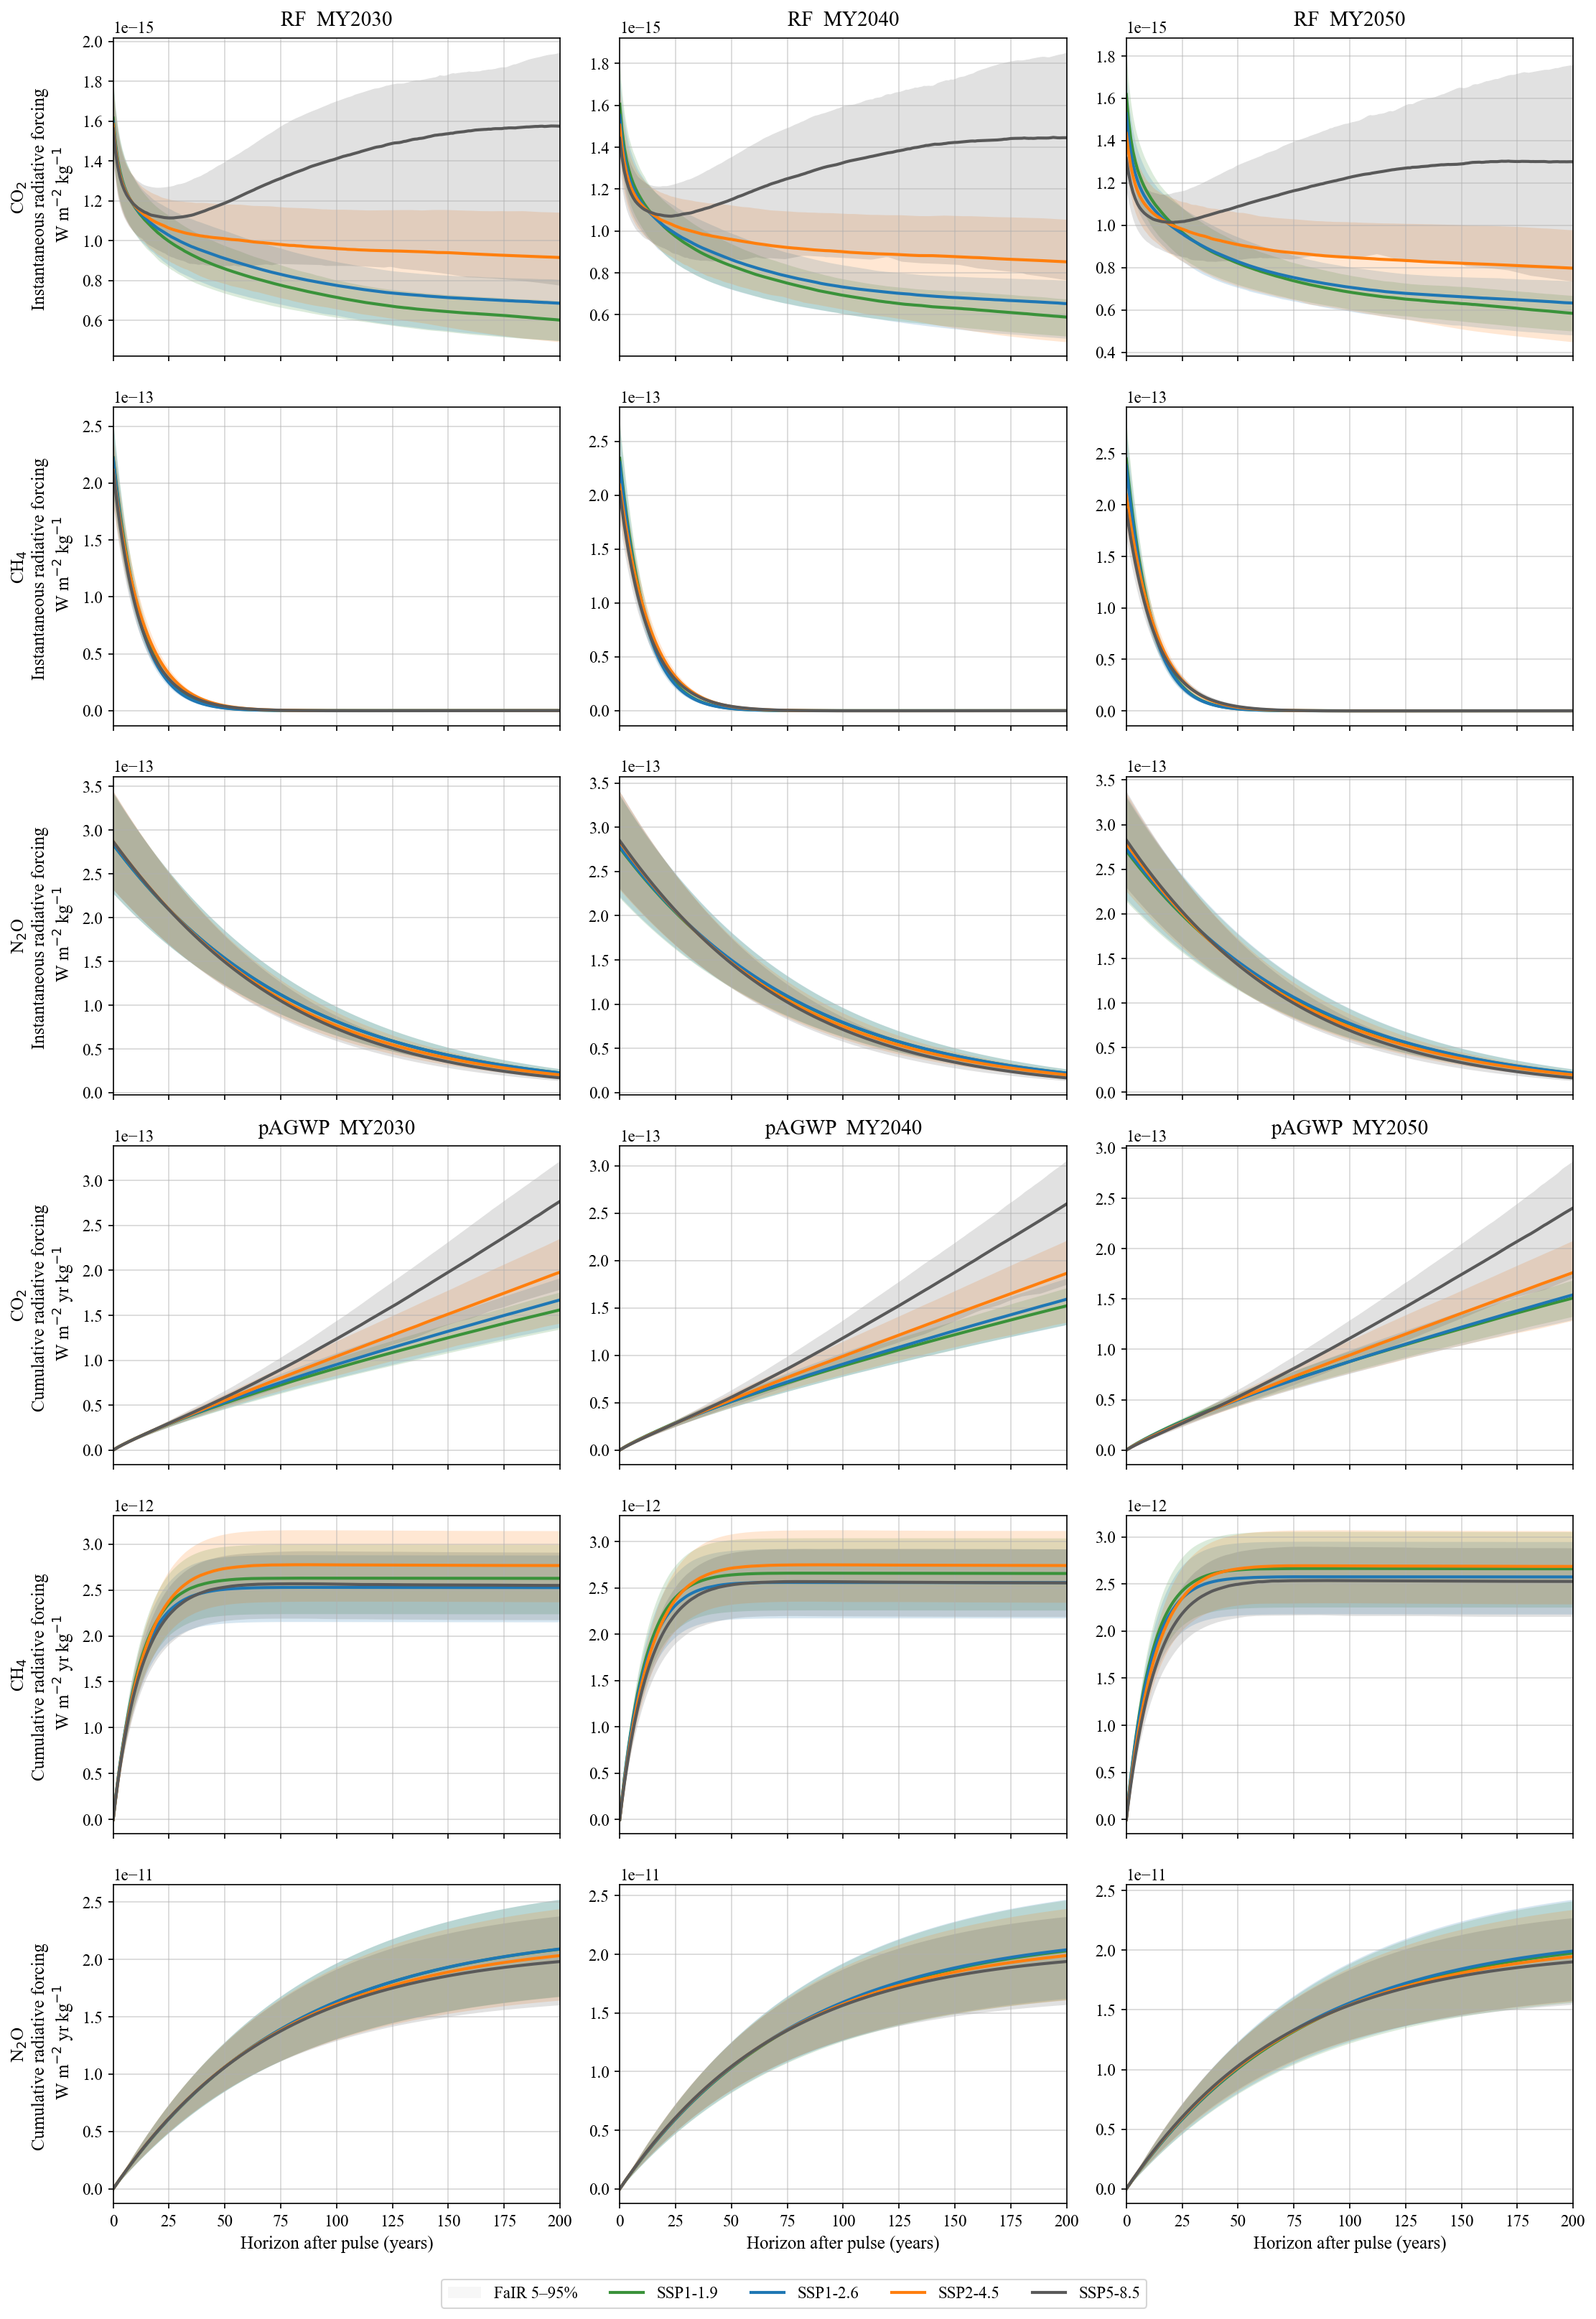

In [32]:

SAVE_FIGURES = True

#save_path = None
if SAVE_FIGURES:
    save_path = out_dir / "absolute_rf_agwp_combined_3x6.png"

#plot_absolute_metrics_combined_3x6(
plot_absolute_metrics_combined_6x3(
    loaded_dict=loaded,
    metrics_order=("rf", "agwp"),
    save_path=save_path,
)


## Notes

- This notebook combines the absolute metrics into a single **3×6** layout.
- Left block: **instantaneous radiative forcing (RF)** for MY2030 / MY2040 / MY2050.
- Right block: **cumulative radiative forcing (pAGWP)** for MY2030 / MY2040 / MY2050.
- For **absolute metrics** (`rf`, `agwp`), the fixed-CO$_2$ versus dp-CO$_2$ distinction does **not** matter. That distinction enters only when converting absolute metrics into **GWP**, because a CO$_2$ denominator is then introduced.
